Импорт необходимых библиотек

In [35]:
from collections import Counter, defaultdict
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

try:
    import spacy
except Exception:
    spacy = None

Сравниваем три варианта обработки:
- spaCy blank("ru")
- ru_core_news_sm
- ru_core_news_lg

Для каждого варианта запускаем анализ без лемматизации и с лемматизацией (где она доступна).

Дополнительно:
- окна: 7-11
- шинглы: Jaccard по словарным шинглам `n=2`
- для шинглов используется лемматизация и удаление стоп-слов

In [36]:
# Настройка шрифта и путей
rcParams["font.sans-serif"] = ["DejaVu Sans"]
rcParams["axes.unicode_minus"] = False

BASE = Path(".").resolve()
TEXT_1 = BASE / "hameleon_short.txt"
TEXT_2 = BASE / "hameleon.txt"
OUT_DIR = BASE / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# Окна только в диапазоне 7-11.
WS = [7, 8, 9, 10, 11]

# Параметры n-граммной и шингл-метрик.
CHAR_NGRAM_N = 2
SHINGLE_WORD_N = 2

Функции анализа и запуск сценария

In [37]:
def load_nlp(kind):
    if kind == "regex":
        return None, "regex fallback"
    if spacy is None:
        return None, "spaCy not installed"
    if kind == "blank":
        return spacy.blank("ru"), "spacy.blank('ru')"
    if kind == "sm":
        try:
            return spacy.load("ru_core_news_sm"), "ru_core_news_sm"
        except Exception as e:
            return None, f"ru_core_news_sm unavailable: {e}"
    if kind == "lg":
        try:
            return spacy.load("ru_core_news_lg"), "ru_core_news_lg"
        except Exception as e:
            return None, f"ru_core_news_lg unavailable: {e}"
    raise ValueError(f"Unknown NLP kind: {kind}")


def get_ru_stopwords(nlp=None):
    if nlp is not None and nlp.vocab is not None:
        # stop_words есть даже у blank("ru").
        sw = {w.lower() for w in nlp.Defaults.stop_words}
        if sw:
            return sw
    if spacy is not None:
        try:
            from spacy.lang.ru.stop_words import STOP_WORDS
            return {w.lower() for w in STOP_WORDS}
        except Exception:
            pass
    return set()


def tok(text, nlp=None, lemmatize=True):
    text = text.lower()
    if nlp is not None:
        doc = nlp(text)
        has_lemmatizer = "lemmatizer" in nlp.pipe_names
        if lemmatize and has_lemmatizer:
            return [
                (t.lemma_.lower() if t.lemma_ and t.lemma_ != "-PRON-" else t.text)
                for t in doc
                if t.text.strip() and t.is_alpha
            ]
        return [t.text for t in doc if t.text.strip() and t.is_alpha]
    return re.findall(r"\w+", text, flags=re.UNICODE)


def tok_for_shingles(text, nlp=None):
    # Для шинглов: леммы + удаление стоп-слов.
    text = text.lower()
    stopwords = get_ru_stopwords(nlp)

    if nlp is not None:
        doc = nlp(text)
        out = []
        has_lemmatizer = "lemmatizer" in nlp.pipe_names
        for t in doc:
            if not (t.text.strip() and t.is_alpha):
                continue
            if t.is_stop or t.text.lower() in stopwords:
                continue
            if has_lemmatizer and t.lemma_ and t.lemma_ != "-PRON-":
                out.append(t.lemma_.lower())
            else:
                out.append(t.text.lower())
        return out

    # Regex fallback: без лемм, но со stopword-фильтром при наличии словаря.
    tokens = re.findall(r"\w+", text, flags=re.UNICODE)
    if not stopwords:
        return tokens
    return [t for t in tokens if t not in stopwords]


def make_windows(words, k):
    return [
        (i, " ".join(words[i : i + k]), set(words[i : i + k]))
        for i in range(max(0, len(words) - k + 1))
    ]


def lev(a, b):
    if a == b:
        return 1.0
    if not a or not b:
        return 0.0
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, c1 in enumerate(a, 1):
        cur = [i]
        for j, c2 in enumerate(b, 1):
            cur.append(min(cur[-1] + 1, prev[j] + 1, prev[j - 1] + (c1 != c2)))
        prev = cur
    return 1 - prev[-1] / max(len(a), len(b))


def jaro(a, b):
    if a == b:
        return 1.0
    if not a or not b:
        return 0.0
    la, lb = len(a), len(b)
    d = max(0, max(la, lb) // 2 - 1)
    ma, mb, m = [0] * la, [0] * lb, 0
    for i in range(la):
        for j in range(max(0, i - d), min(i + d + 1, lb)):
            if not mb[j] and a[i] == b[j]:
                ma[i] = mb[j] = 1
                m += 1
                break
    if m == 0:
        return 0.0
    t, j = 0, 0
    for i in range(la):
        if not ma[i]:
            continue
        while not mb[j]:
            j += 1
        t += a[i] != b[j]
        j += 1
    return (m / la + m / lb + (m - t / 2) / m) / 3


def winkler(a, b, p=0.1, bt=0.7):
    dj = jaro(a, b)
    if dj <= bt:
        return dj
    pref = 0
    for x, y in zip(a[:4], b[:4]):
        if x != y:
            break
        pref += 1
    return dj + pref * p * (1 - dj)


def jaccard(a, b, n=2):
    def ng(s):
        if len(s) < n:
            return {s} if s else set()
        return {s[i : i + n] for i in range(len(s) - n + 1)}

    x, y = ng(a), ng(b)
    if not x and not y:
        return 1.0
    if not x or not y:
        return 0.0
    return len(x & y) / len(x | y)


def shingle_jaccard(a, b, shingle_n=2):
    def shingles(s):
        words = s.split()
        if len(words) < shingle_n:
            return {" ".join(words)} if words else set()
        return {
            " ".join(words[i : i + shingle_n])
            for i in range(len(words) - shingle_n + 1)
        }

    x, y = shingles(a), shingles(b)
    if not x and not y:
        return 1.0
    if not x or not y:
        return 0.0
    return len(x & y) / len(x | y)


def best_thr(vals, method):
    # Bugfix: если нет кандидатов, порог должен быть 0.0, а не 1.0.
    if vals.size == 0:
        return 0.0
    grid = np.arange(0.65, 1.001, 0.01) if method in {"jaro", "jaro_winkler"} else (
        np.arange(0.55, 1.001, 0.01) if method == "levenshtein" else np.arange(0.35, 1.001, 0.01)
    )
    best_t, best_q = float(grid[0]), -1.0
    for t in grid:
        s = vals[vals >= t]
        if s.size == 0:
            continue
        q = 0.65 * float(np.mean(s)) + 0.35 * (s.size / vals.size)
        if q > best_q:
            best_t, best_q = float(t), q
    return best_t


def score_pairs(w1, w2, sim, min_overlap):
    idx = defaultdict(list)
    for j, (_, _, terms) in enumerate(w2):
        for term in terms:
            idx[term].append(j)

    out = []
    for _, p1, t1 in w1:
        c = Counter()
        for term in t1:
            for j in idx.get(term, []):
                c[j] += 1
        for j, ov in c.items():
            if ov >= min_overlap:
                out.append((p1, sim(p1, w2[j][1])))
    return out


def analyze(words1, words2, shingle_words1=None, shingle_words2=None, ws=None, n=2, shingle_n=2, p=0.1, bt=0.7):
    if ws is None:
        ws = WS

    if shingle_words1 is None:
        shingle_words1 = words1
    if shingle_words2 is None:
        shingle_words2 = words2

    stats = defaultdict(dict)

    base_methods = {
        "levenshtein": lev,
        "jaro": jaro,
        "jaro_winkler": lambda a, b: winkler(a, b, p, bt),
        "jaccard_char": lambda a, b: jaccard(a, b, n),
    }

    for name, sim in base_methods.items():
        for k in ws:
            w1, w2 = make_windows(words1, k), make_windows(words2, k)
            scored = score_pairs(w1, w2, sim, max(1, math.ceil(k * 0.35)))
            vals = np.array([x[1] for x in scored], dtype=float)
            thr = best_thr(vals, name)
            matched = [x for x in scored if x[1] >= thr]
            total = sum(len(x[0]) for x in matched)
            avg = float(np.mean([x[1] for x in matched])) if matched else 0.0
            stats[name][k] = {
                "threshold": thr,
                "matches_count": len(matched),
                "total_length": int(total),
                "avg_similarity": avg,
            }

    # Отдельно считаем шинглы по леммам и без стоп-слов.
    for k in ws:
        w1s, w2s = make_windows(shingle_words1, k), make_windows(shingle_words2, k)
        scored = score_pairs(w1s, w2s, lambda a, b: shingle_jaccard(a, b, shingle_n), max(1, math.ceil(k * 0.35)))
        vals = np.array([x[1] for x in scored], dtype=float)
        thr = best_thr(vals, "jaccard_shingle")
        matched = [x for x in scored if x[1] >= thr]
        total = sum(len(x[0]) for x in matched)
        avg = float(np.mean([x[1] for x in matched])) if matched else 0.0
        stats["jaccard_shingle"][k] = {
            "threshold": thr,
            "matches_count": len(matched),
            "total_length": int(total),
            "avg_similarity": avg,
        }

    return stats


def print_summary(stats, ws):
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 64)
    for m in stats:
        cnt = sum(stats[m][k]["matches_count"] for k in ws)
        ln = sum(stats[m][k]["total_length"] for k in ws)
        print(f"{m:>15}: совпадений={cnt:>4}, суммарная длина={ln:>5}")


def plot(stats, ws, out_dir, suffix):
    methods = list(stats)
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Схожесть текстов ({suffix})", fontsize=14)
    items = [
        ("matches_count", "Количество совпадений", "o", None),
        ("total_length", "Суммарная длина", "s", None),
        ("avg_similarity", "Средняя схожесть", "^", (0, 1)),
        ("threshold", "Оптимальные пороги", "D", (0, 1)),
    ]
    for a, (key, title, marker, ylim) in zip(ax.flat, items):
        for m in methods:
            a.plot(ws, [stats[m][k][key] for k in ws], marker=marker, linewidth=2, label=m)
        a.set_title(title)
        a.set_xlabel("Размер окна (слов)")
        if ylim:
            a.set_ylim(*ylim)
        a.grid(alpha=0.3)
        a.legend()
    plt.tight_layout()
    img = out_dir / f"similarity_analysis_{suffix}.png"
    plt.savefig(img, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Сохранен график: {img}")


def run_scenario(nlp_kind, use_lemmatization):
    nlp, nlp_label = load_nlp(nlp_kind)
    print("\n" + "#" * 80)
    print(f"СЦЕНАРИЙ: {nlp_kind} | lemmatize={use_lemmatization}")
    print(f"Источник NLP: {nlp_label}")
    print(f"Окна: {WS}")
    print(f"Параметры: char_n={CHAR_NGRAM_N}, shingle_word_n={SHINGLE_WORD_N}")

    if nlp is None and nlp_kind != "regex":
        print("Сценарий пропущен: модель недоступна.")
        return

    if nlp is not None:
        has_lem = "lemmatizer" in nlp.pipe_names
        print(f"Пайплайн: {nlp.pipe_names}")
        print(f"Лемматизатор в пайплайне: {has_lem}")
        if use_lemmatization and not has_lem:
            print("Внимание: запрошена лемматизация, но она недоступна для этой модели.")
    else:
        print("Пайплайн: regex fallback")

    words1 = tok(TEXT_1.read_text(encoding="utf-8"), nlp=nlp, lemmatize=use_lemmatization)
    words2 = tok(TEXT_2.read_text(encoding="utf-8"), nlp=nlp, lemmatize=use_lemmatization)

    # Для шинглов всегда используем леммы и убираем stopwords.
    shingle_words1 = tok_for_shingles(TEXT_1.read_text(encoding="utf-8"), nlp=nlp)
    shingle_words2 = tok_for_shingles(TEXT_2.read_text(encoding="utf-8"), nlp=nlp)

    print(f"Текст 1: {len(words1)} токенов")
    print(f"Текст 2: {len(words2)} токенов")
    print(f"Шингл-токены 1 (леммы без стоп-слов): {len(shingle_words1)}")
    print(f"Шингл-токены 2 (леммы без стоп-слов): {len(shingle_words2)}")

    stats = analyze(
        words1,
        words2,
        shingle_words1=shingle_words1,
        shingle_words2=shingle_words2,
        ws=WS,
        n=CHAR_NGRAM_N,
        shingle_n=SHINGLE_WORD_N,
        p=0.1,
        bt=0.7,
    )
    print_summary(stats, WS)

    suffix = f"{nlp_kind}_{'lem' if use_lemmatization else 'nolem'}"
    plot(stats, WS, OUT_DIR, suffix)

In [38]:
# PATCH: исправление шинглов (слишком жесткий порог и фильтр кандидатов)
def best_thr(vals, method):
    # Если кандидатов нет, возвращаем нулевой порог.
    if vals.size == 0:
        return 0.0

    if method in {"jaro", "jaro_winkler"}:
        grid = np.arange(0.65, 1.001, 0.01)
    elif method == "levenshtein":
        grid = np.arange(0.55, 1.001, 0.01)
    elif method == "jaccard_shingle":
        # Для шинглов значения обычно ниже, чем для char-jaccard.
        grid = np.arange(0.05, 1.001, 0.01)
    else:
        grid = np.arange(0.35, 1.001, 0.01)

    best_t, best_q = float(grid[0]), -1.0
    for t in grid:
        s = vals[vals >= t]
        if s.size == 0:
            continue
        q = 0.65 * float(np.mean(s)) + 0.35 * (s.size / vals.size)
        if q > best_q:
            best_t, best_q = float(t), q
    return best_t


def analyze(words1, words2, shingle_words1=None, shingle_words2=None, ws=None, n=2, shingle_n=2, p=0.1, bt=0.7):
    if ws is None:
        ws = WS

    if shingle_words1 is None:
        shingle_words1 = words1
    if shingle_words2 is None:
        shingle_words2 = words2

    stats = defaultdict(dict)

    base_methods = {
        "levenshtein": lev,
        "jaro": jaro,
        "jaro_winkler": lambda a, b: winkler(a, b, p, bt),
        "jaccard_char": lambda a, b: jaccard(a, b, n),
    }

    for name, sim in base_methods.items():
        for k in ws:
            w1, w2 = make_windows(words1, k), make_windows(words2, k)
            scored = score_pairs(w1, w2, sim, max(1, math.ceil(k * 0.35)))
            vals = np.array([x[1] for x in scored], dtype=float)
            thr = best_thr(vals, name)
            matched = [x for x in scored if x[1] >= thr]
            total = sum(len(x[0]) for x in matched)
            avg = float(np.mean([x[1] for x in matched])) if matched else 0.0
            stats[name][k] = {
                "threshold": thr,
                "matches_count": len(matched),
                "total_length": int(total),
                "avg_similarity": avg,
            }

    # Для шинглов используем более мягкий pre-filter, иначе почти все пары отсеиваются.
    for k in ws:
        w1s, w2s = make_windows(shingle_words1, k), make_windows(shingle_words2, k)
        min_overlap_shingle = max(1, math.ceil(k * 0.15))
        scored = score_pairs(
            w1s,
            w2s,
            lambda a, b: shingle_jaccard(a, b, shingle_n),
            min_overlap_shingle,
        )
        vals = np.array([x[1] for x in scored], dtype=float)
        thr = best_thr(vals, "jaccard_shingle")
        matched = [x for x in scored if x[1] >= thr]
        total = sum(len(x[0]) for x in matched)
        avg = float(np.mean([x[1] for x in matched])) if matched else 0.0
        stats["jaccard_shingle"][k] = {
            "threshold": thr,
            "matches_count": len(matched),
            "total_length": int(total),
            "avg_similarity": avg,
        }

    return stats

## 1) Базовый сценарий: без NLP (regex)
Сначала смотрим baseline без spaCy, чтобы было с чем сравнивать модели.


################################################################################
СЦЕНАРИЙ: regex | lemmatize=False
Источник NLP: regex fallback
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: regex fallback
Текст 1: 281 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 185
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  30, суммарная длина= 1780
           jaro: совпадений= 223, суммарная длина=14837
   jaro_winkler: совпадений= 223, суммарная длина=14837
   jaccard_char: совпадений= 184, суммарная длина=12300
jaccard_shingle: совпадений= 706, суммарная длина=62490


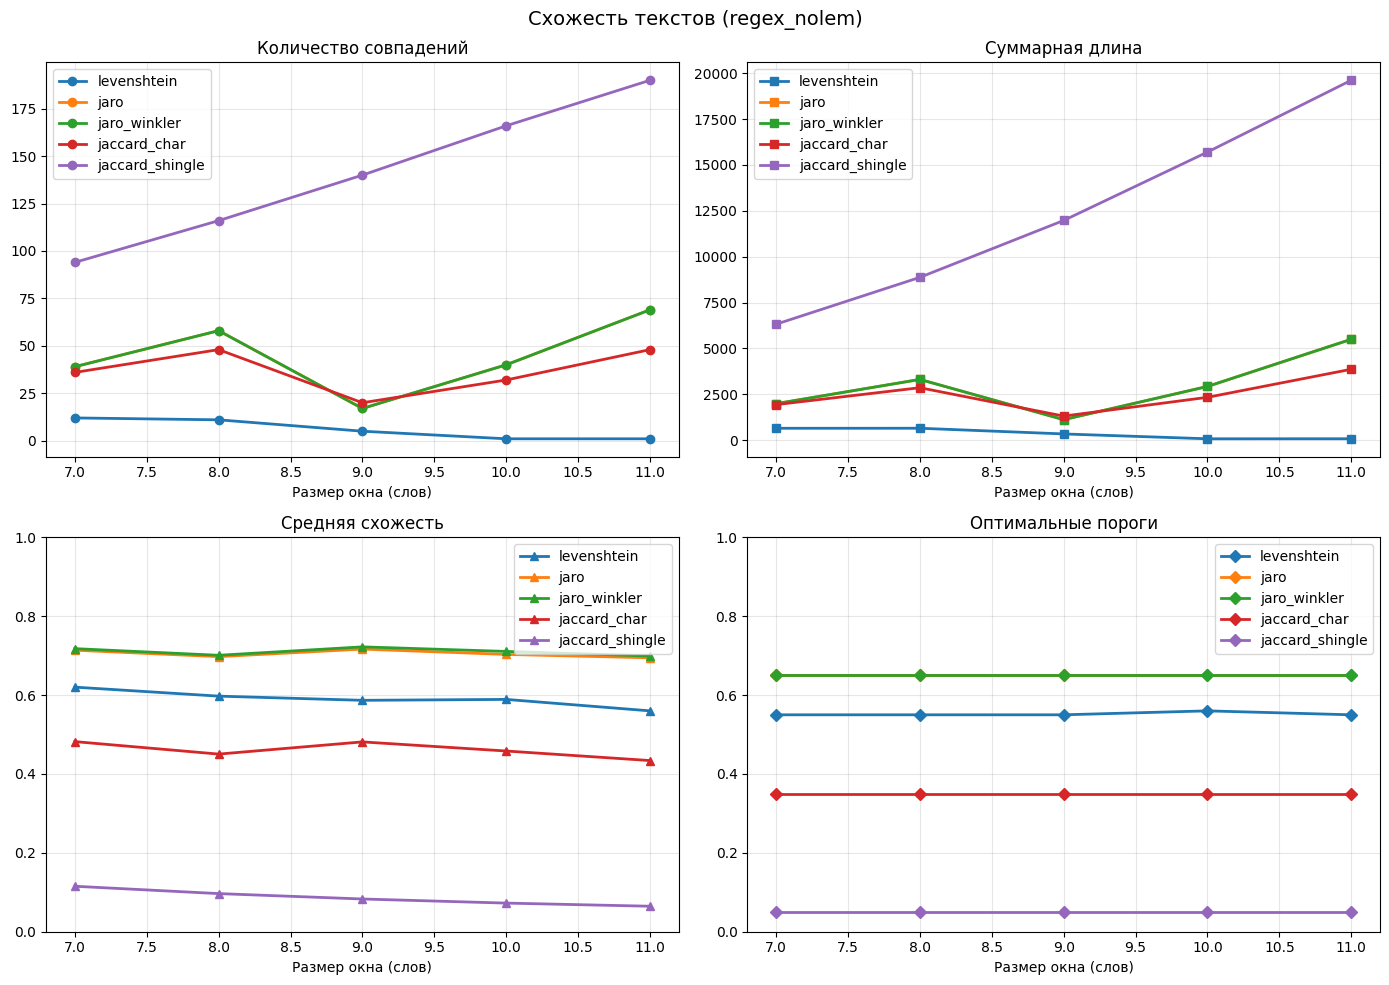

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_regex_nolem.png


In [39]:
# Baseline: regex fallback, без лемматизации
run_scenario("regex", False)

## 2) spaCy blank("ru")
Без лемматизации.


################################################################################
СЦЕНАРИЙ: blank | lemmatize=False
Источник NLP: spacy.blank('ru')
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: []
Лемматизатор в пайплайне: False
Текст 1: 272 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 178
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  30, суммарная длина= 1780
           jaro: совпадений= 224, суммарная длина=14897
   jaro_winkler: совпадений= 224, суммарная длина=14897
   jaccard_char: совпадений= 184, суммарная длина=12300
jaccard_shingle: совпадений= 706, суммарная длина=62490


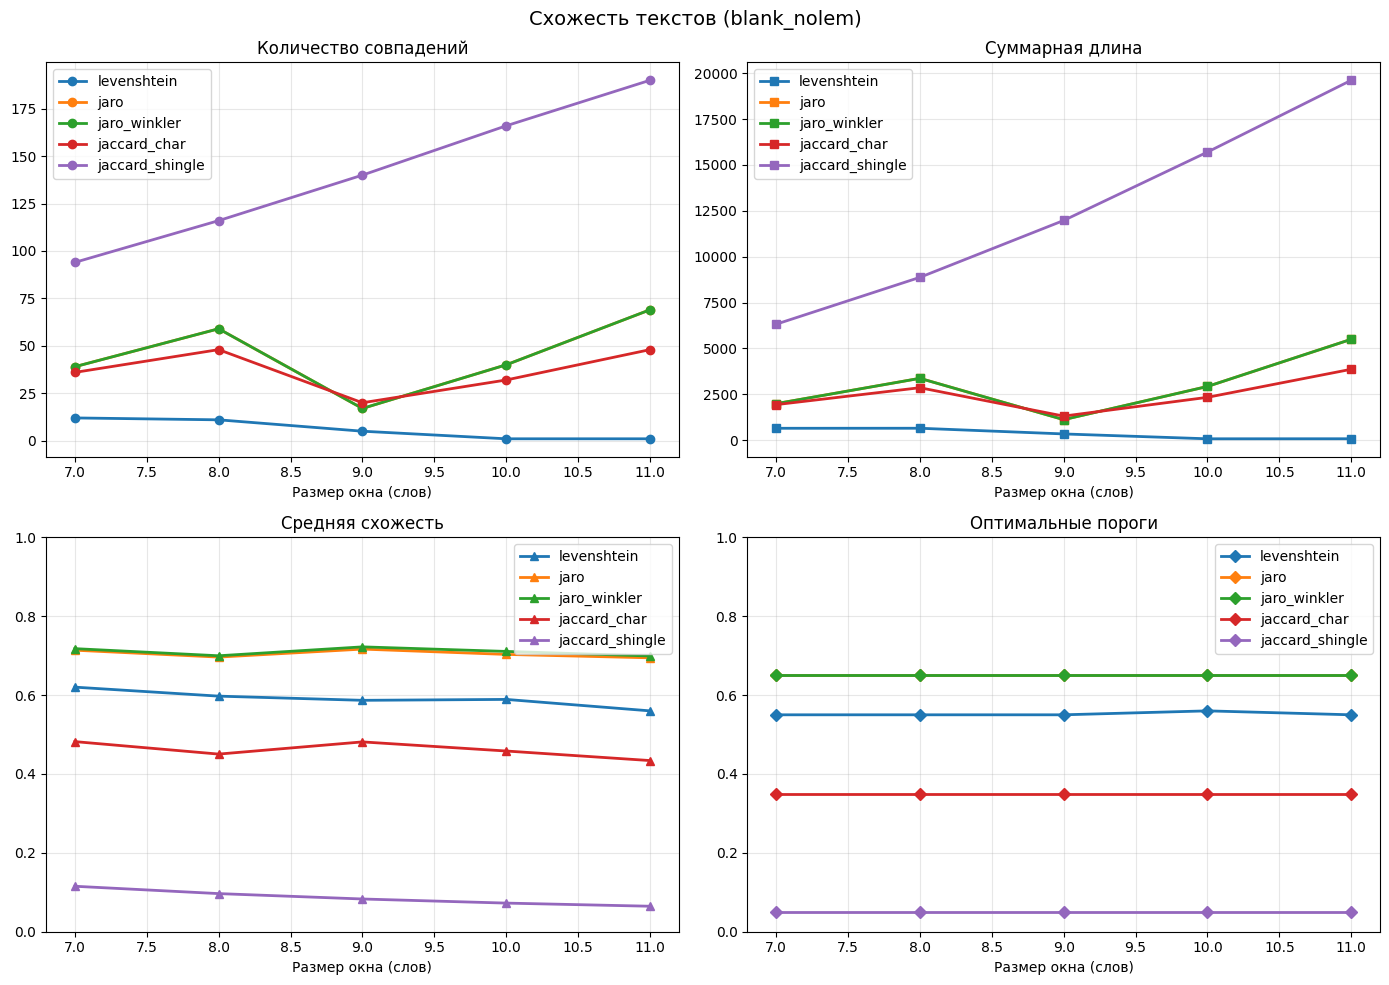

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_blank_nolem.png


In [40]:
# blank("ru"), без лемматизации
run_scenario("blank", False)

## 3) ru_core_news_sm
Сначала без лемматизации, затем с лемматизацией.


################################################################################
СЦЕНАРИЙ: sm | lemmatize=False
Источник NLP: ru_core_news_sm
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Лемматизатор в пайплайне: True
Текст 1: 272 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 178
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  30, суммарная длина= 1780
           jaro: совпадений= 224, суммарная длина=14897
   jaro_winkler: совпадений= 224, суммарная длина=14897
   jaccard_char: совпадений= 184, суммарная длина=12300
jaccard_shingle: совпадений= 706, суммарная длина=60815


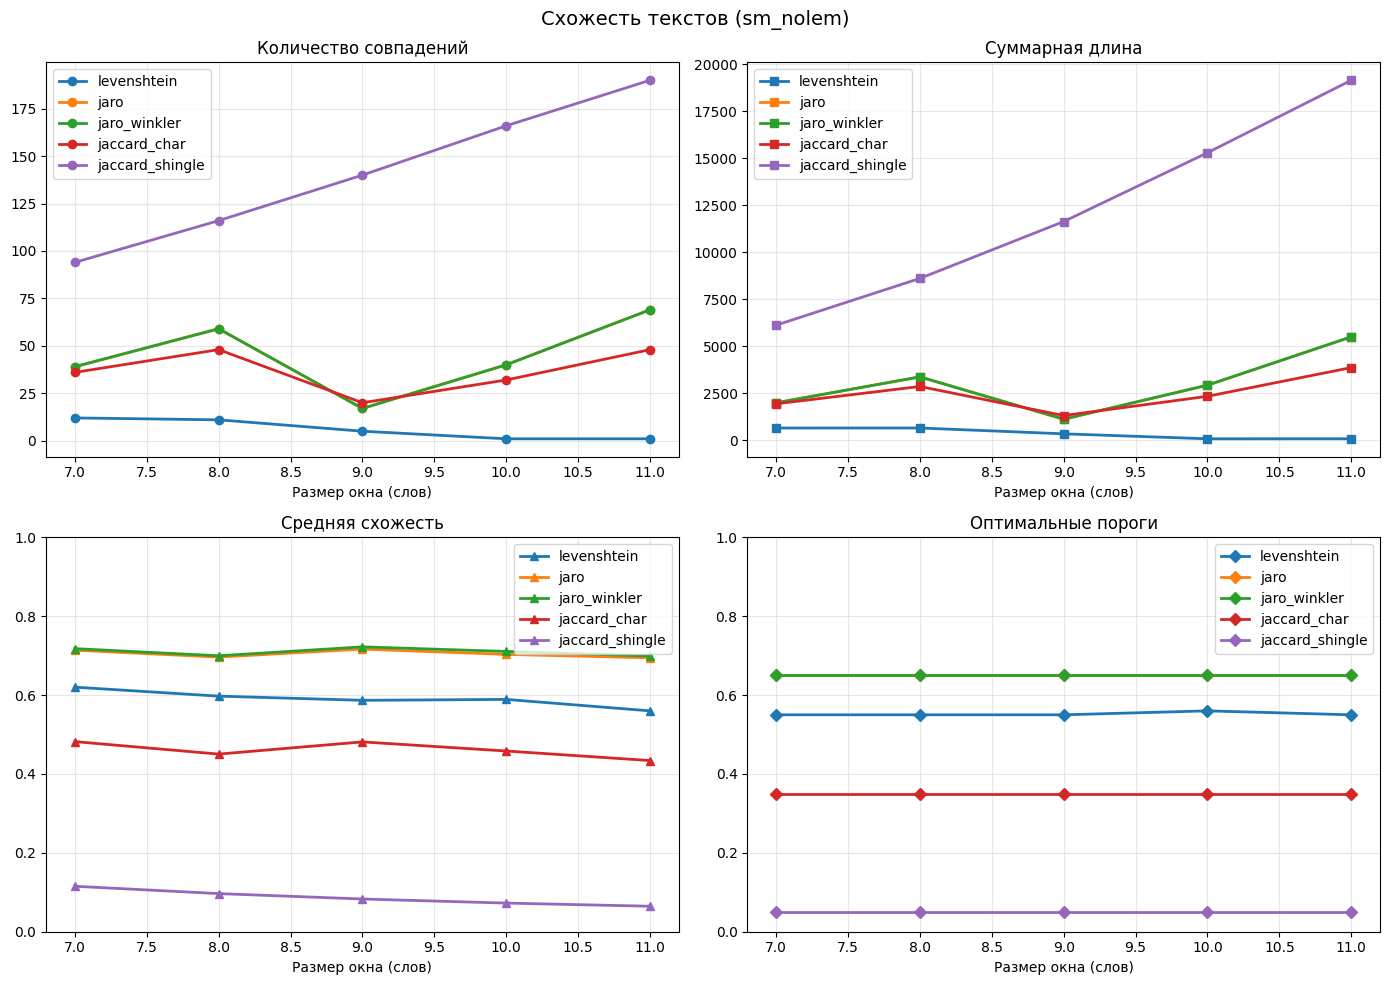

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_sm_nolem.png


In [41]:
# ru_core_news_sm, без лемматизации
run_scenario("sm", False)


################################################################################
СЦЕНАРИЙ: sm | lemmatize=True
Источник NLP: ru_core_news_sm
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Лемматизатор в пайплайне: True
Текст 1: 272 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 178
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  35, суммарная длина= 2084
           jaro: совпадений= 237, суммарная длина=15269
   jaro_winkler: совпадений= 237, суммарная длина=15269
   jaccard_char: совпадений= 193, суммарная длина=12727
jaccard_shingle: совпадений= 706, суммарная длина=60815


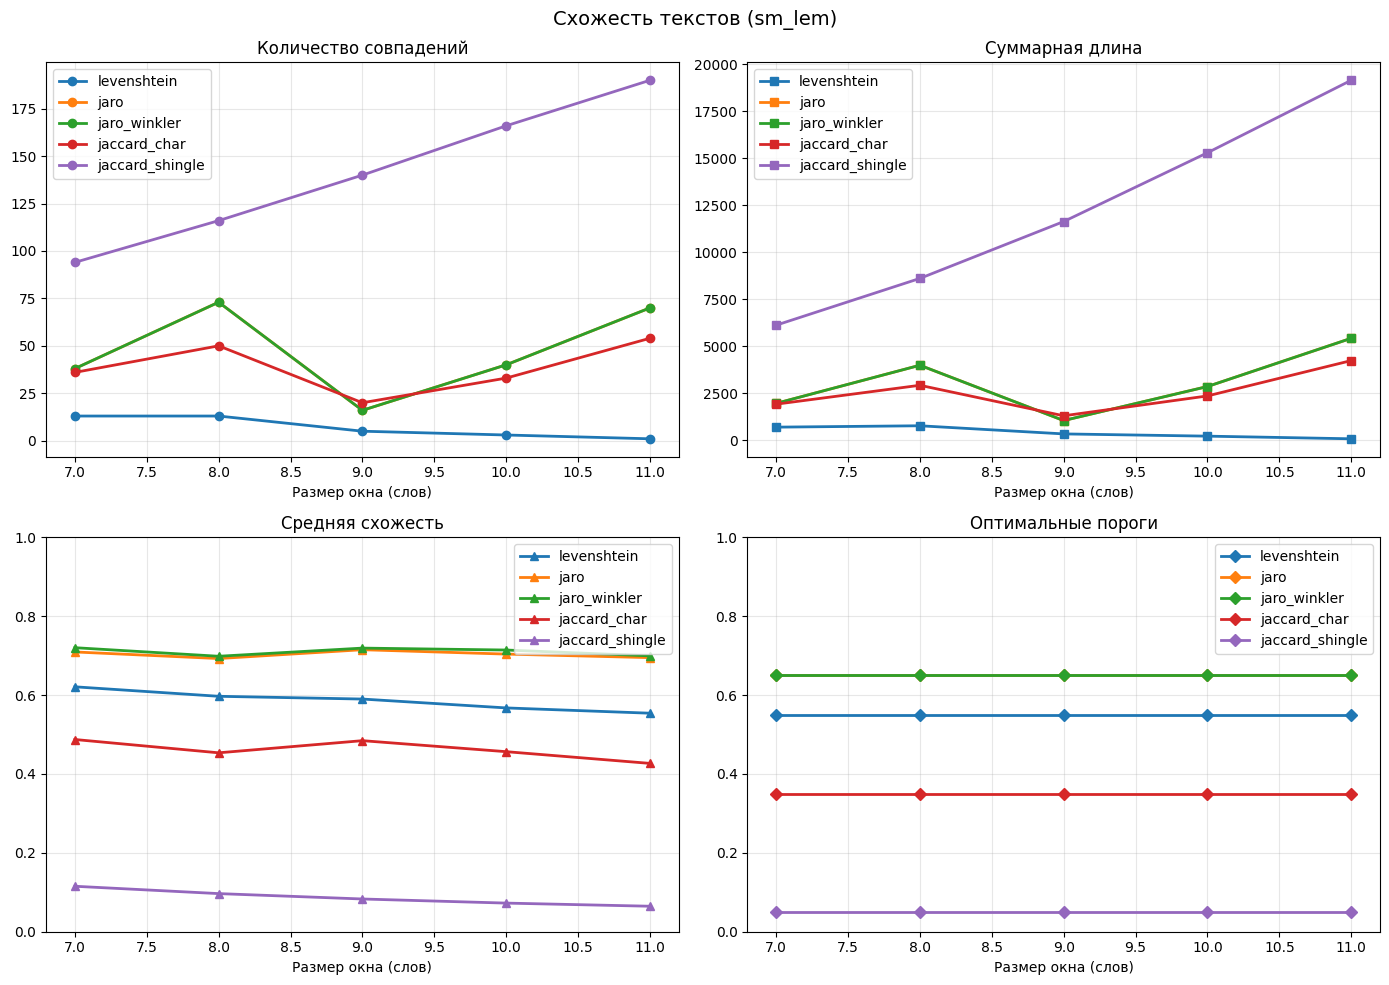

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_sm_lem.png


In [42]:
# ru_core_news_sm, с лемматизацией
run_scenario("sm", True)

## 4) ru_core_news_lg
Сначала без лемматизации, затем с лемматизацией.


################################################################################
СЦЕНАРИЙ: lg | lemmatize=False
Источник NLP: ru_core_news_lg
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Лемматизатор в пайплайне: True
Текст 1: 272 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 178
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  30, суммарная длина= 1780
           jaro: совпадений= 224, суммарная длина=14897
   jaro_winkler: совпадений= 224, суммарная длина=14897
   jaccard_char: совпадений= 184, суммарная длина=12300
jaccard_shingle: совпадений= 706, суммарная длина=60815


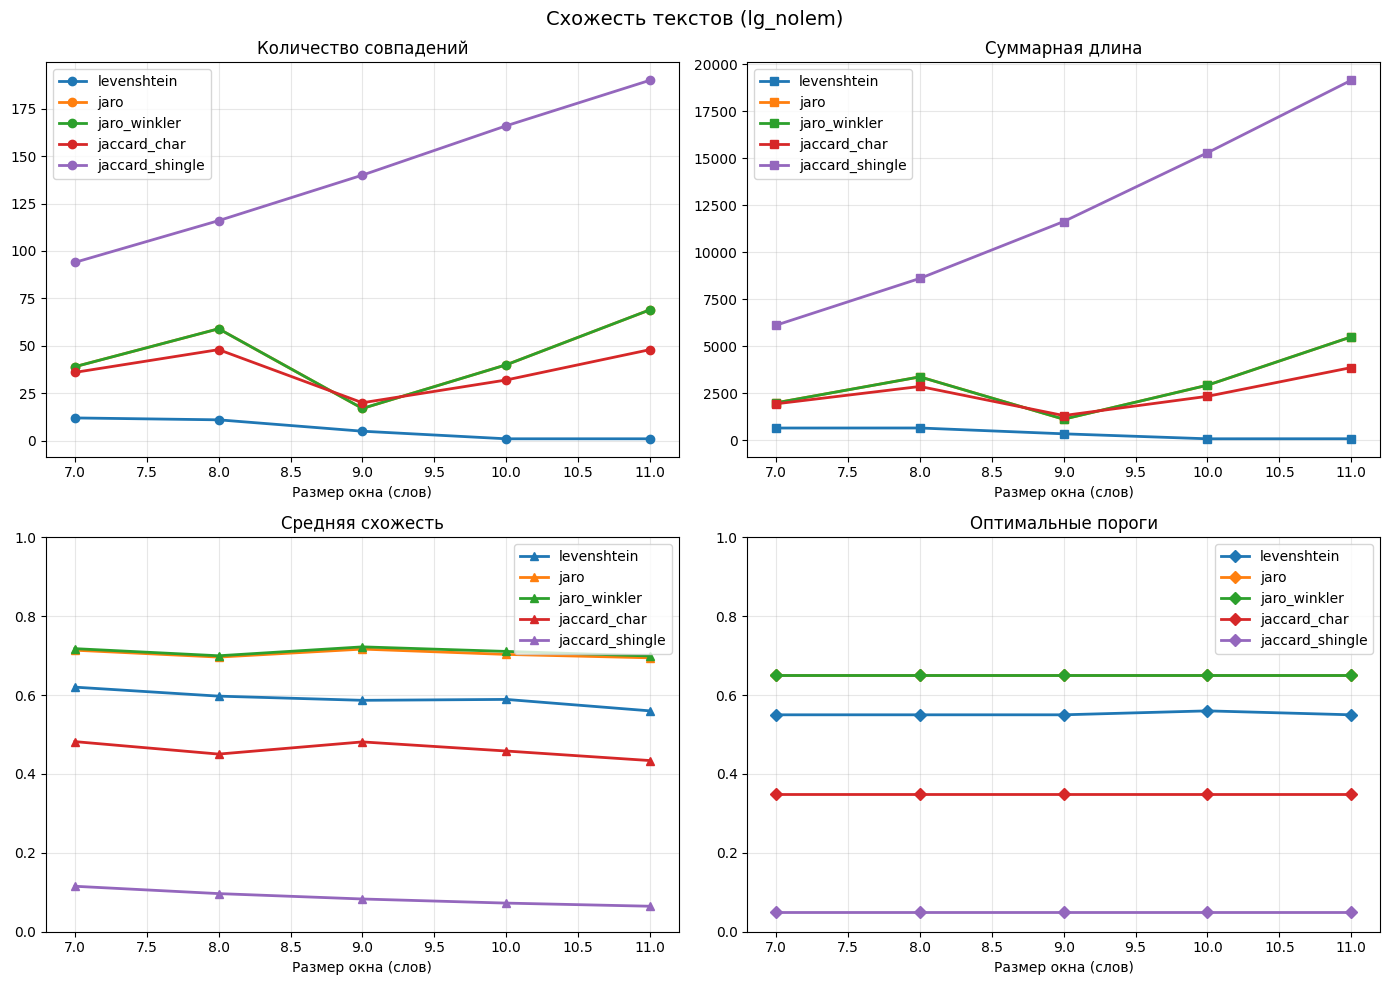

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_lg_nolem.png


In [43]:
# ru_core_news_lg, без лемматизации
run_scenario("lg", False)


################################################################################
СЦЕНАРИЙ: lg | lemmatize=True
Источник NLP: ru_core_news_lg
Окна: [7, 8, 9, 10, 11]
Параметры: char_n=2, shingle_word_n=2
Пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Лемматизатор в пайплайне: True
Текст 1: 272 токенов
Текст 2: 908 токенов
Шингл-токены 1 (леммы без стоп-слов): 178
Шингл-токены 2 (леммы без стоп-слов): 487
ИТОГОВАЯ СВОДКА
    levenshtein: совпадений=  35, суммарная длина= 2084
           jaro: совпадений= 237, суммарная длина=15270
   jaro_winkler: совпадений= 237, суммарная длина=15270
   jaccard_char: совпадений= 193, суммарная длина=12727
jaccard_shingle: совпадений= 706, суммарная длина=60815


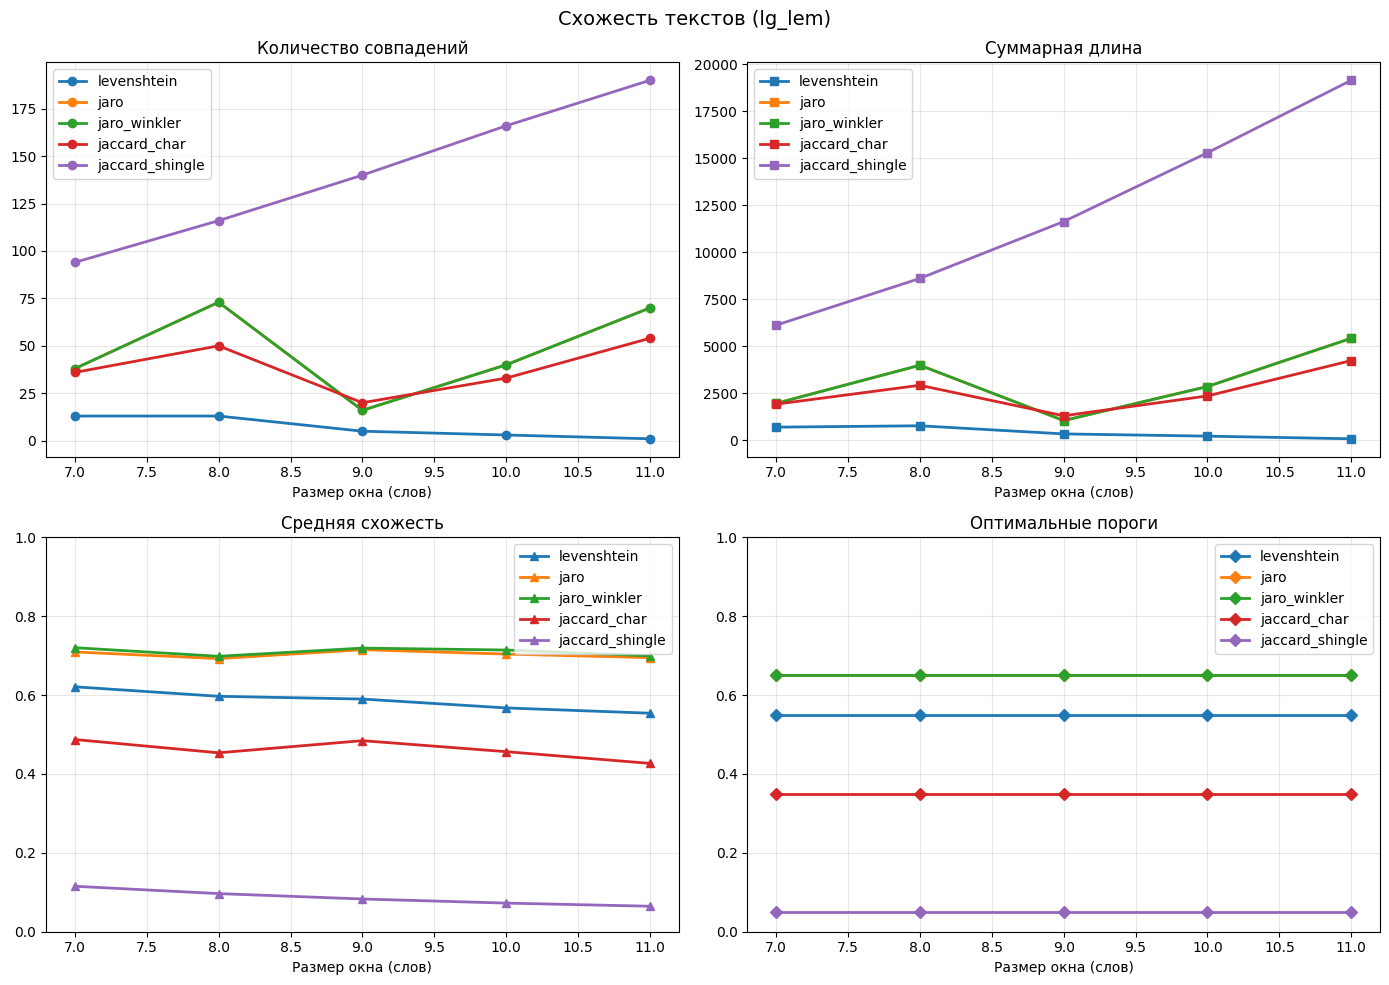

Сохранен график: /home/ada/Documents/Projects/Mephi/S8/IRFM/LR4/outputs/similarity_analysis_lg_lem.png


In [44]:
# ru_core_news_lg, с лемматизацией
run_scenario("lg", True)

## 5) Итоговая оценка и классификация
Правила:
- `score` = максимум `Jaro-Winkler` по всем окнам
- `score >= 0.65` -> `similar`
- `score >= 0.55` -> `partial`
- иначе -> `different`

Крайние случаи:
- если совпадений нет, `score = 0`
- для Jaccard предусмотрен безопасный расчет без деления на 0

In [45]:
def classify_similarity(score):
    if score >= 0.65:
        return "similar"
    if score >= 0.55:
        return "partial"
    return "different"


def safe_jaccard_set(x, y):
    # Защита от деления на 0 для любых Jaccard-расчетов.
    if not x and not y:
        return 1.0
    if not x or not y:
        return 0.0
    union = x | y
    if not union:
        return 0.0
    return len(x & y) / len(union)


def final_assessment(nlp_kind="sm", use_lemmatization=True, ws=None):
    if ws is None:
        ws = WS

    nlp, nlp_label = load_nlp(nlp_kind)
    print(f"Источник NLP: {nlp_label}")

    if nlp is None and nlp_kind != "regex":
        result = {"score": 0.0, "category": "different"}
        print(result)
        return result

    words1 = tok(TEXT_1.read_text(encoding="utf-8"), nlp=nlp, lemmatize=use_lemmatization)
    words2 = tok(TEXT_2.read_text(encoding="utf-8"), nlp=nlp, lemmatize=use_lemmatization)

    max_score = 0.0
    has_matches = False

    for k in ws:
        w1, w2 = make_windows(words1, k), make_windows(words2, k)
        scored = score_pairs(
            w1,
            w2,
            lambda a, b: winkler(a, b, p=0.1, bt=0.7),
            max(1, math.ceil(k * 0.35)),
        )
        if not scored:
            continue
        has_matches = True
        best_k = max(s for _, s in scored)
        if best_k > max_score:
            max_score = float(best_k)

    score = max_score if has_matches else 0.0
    category = classify_similarity(score)

    result = {
        "score": round(score, 4),
        "category": category,
    }
    print(result)
    return result


# Пример запуска итоговой оценки
final_assessment(nlp_kind="lg", use_lemmatization=True)

Источник NLP: ru_core_news_lg
{'score': 0.9244, 'category': 'similar'}


{'score': 0.9244, 'category': 'similar'}